<a href="https://colab.research.google.com/github/sasaitals/Data-Science-testando-rela-es-com-Regress-o-Linear/blob/main/Usina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.express as px
import seaborn as sns


In [80]:
dados = pd.read_csv("/content/usina.csv")
dados.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [81]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [83]:
y = dados['PE']
x = dados.drop(columns = 'PE')

In [84]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=230)

In [100]:
x_treino= sm.add_constant(x_treino)

In [101]:
modelo = sm.OLS(y_treino,x_treino).fit()

In [102]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:43:05   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.0

In [105]:
explicativas = ['const','AT','V','AP','RH']

In [106]:
vif_1 = pd.DataFrame()
vif_1["variavel"] = explicativas

vif_1["vif"] = [variance_inflation_factor(x_treino[explicativas].values, i)
                          for i in range(len(explicativas))]

vif_1
#Os dados abaixo está batendo com a resposta, arquivo disponibilizado pela alura

,variavel,vif
0,const,1.000000
1,AT,6.034363
2,V,3.954998
3,AP,1.468530
4,RH,1.717508


In [89]:
x_treino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6697 entries, 3522 to 6867
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      6697 non-null   float64
 1   V       6697 non-null   float64
 2   AP      6697 non-null   float64
 3   RH      6697 non-null   float64
dtypes: float64(4)
memory usage: 261.6 KB


In [90]:
explicativas = ['const','AT','V','AP','RH']

In [95]:
vif_1 = pd.DataFrame()
vif_1["variavel"] = explicativas

vif_1["vif"] = [variance_inflation_factor(x_treino[explicativas].values, i)
                          for i in range(len(explicativas))]

vif_1
#Os dados abaixo está batendo com a resposta, arquivo disponibilizado pela alura

,variavel,vif
0,const,1.000000
1,AT,6.034363
2,V,3.954998
3,AP,1.468530
4,RH,1.717508


In [108]:
y_previsto_train =  modelo.predict(x_treino)

In [109]:
fig = px.scatter(x=y_previsto_train, y=y_treino,
                 title='Previsão e Real',
                 labels={'x':'Previsão','y':'Real'})
fig.show()

In [110]:
residuos = modelo.resid

In [111]:
fig = px.scatter(x=y_previsto_train, y=residuos,
                 title='Previsão e Real',
                 labels={'x':'Previsão','y':'Real'})
fig.show()

<Axes: title={'center': 'Resíduos X Previsão'}, xlabel='PE', ylabel='Resíduos'>

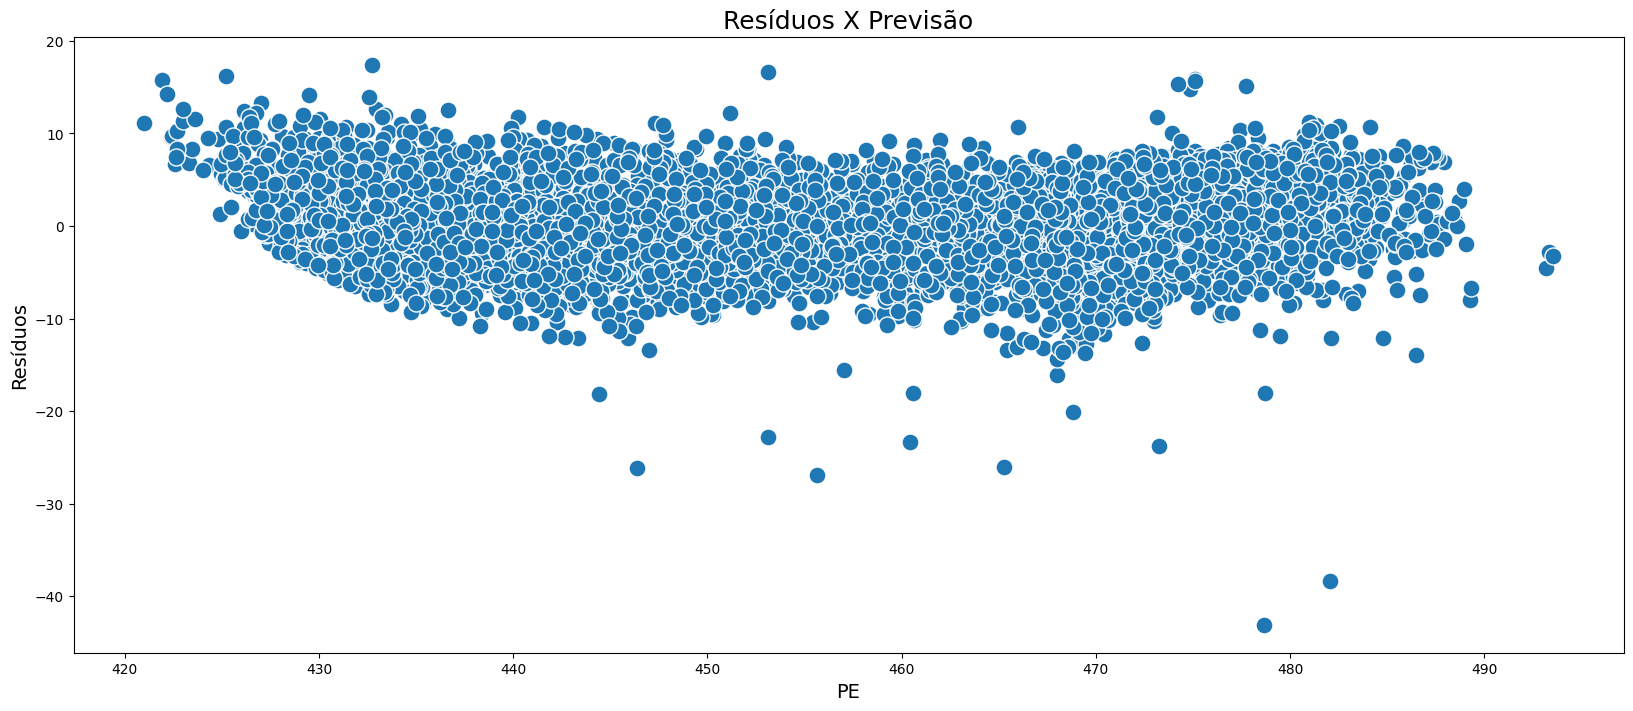

In [114]:
ax = sns.scatterplot(x = y_previsto_train, y=residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Resíduos X Previsão', fontsize=18)
ax.set_xlabel('PE', fontsize=14)
ax.set_ylabel('Resíduos', fontsize=14)
ax

#Este modelo não tem variação em relação a residuos, como o modelo da aula
#A grande maioria dos residos estão em y0